<span style="color:green; font-size:26px; font-weight:bold;">MODELO 1: </span>

<span style="color:green; font-size:33px; font-weight:bold;">REGRESION LINEAL_V2 (sin variables demográficas)</span>

________________________________________________________________________________________________________________________________


### Justificación   

La Regresión Lineal se utiliza como modelo base de referencia para el problema de predicción de la satisfacción con la vida. Este algoritmo estima la relación lineal existente entre la variable objetivo y el conjunto de variables explicativas seleccionadas.

Su principal ventaja es la facilidad de interpretación de los resultados, ya que permite analizar la influencia de cada variable predictora sobre la satisfacción vital. Además, constituye un punto de partida adecuado para comparar posteriormente el rendimiento de modelos más complejos basados en árboles de decisión y técnicas de ensamblado.

Aunque la relación entre las variables puede no ser estrictamente lineal, la Regresión Lineal proporciona una primera aproximación al problema y permite establecer una línea base de rendimiento frente a la cual evaluar el resto de modelos.


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle

In [2]:
df_modelo = pd.read_csv("../1_Data/processed.csv", sep = ",")

df_modelo

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5279,1,1,4,1,1,2,1,3,7,9,8,7,8,9,8,8,4,6,6
5280,1,6,7,4,1,1,3,1,6,8,7,3,6,7,10,8,3,5,6
5281,1,6,3,5,1,2,3,2,4,5,5,5,5,8,5,7,3,5,5
5282,1,1,5,4,1,1,1,3,8,8,9,8,8,8,7,8,3,7,5


In [3]:
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 5284 entries, 0 to 5283
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Terr_hist              5284 non-null   int64
 1   Sexo                   5284 non-null   int64
 2   Edad_interv            5284 non-null   int64
 3   Lugar_nacim            5284 non-null   int64
 4   Nacionalidad           5284 non-null   int64
 5   Nivel_estudios         5284 non-null   int64
 6   Actividad              5284 non-null   int64
 7   Tipo_hogar             5284 non-null   int64
 8   Target_Satisfacc_Vida  5284 non-null   int64
 9   Satisf_relac_pers      5284 non-null   int64
 10  Sentido_propia_vida    5284 non-null   int64
 11  Satisf_econom_domest   5284 non-null   int64
 12  Valor_Estado_animo     5284 non-null   int64
 13  Satisf_vivienda        5284 non-null   int64
 14  Satisf_tiempo_disp     5284 non-null   int64
 15  Satisf_viv_y_entorno   5284 non-null   int64
 16 

In [4]:
df_modelo.describe(include='all')

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
count,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000
mean,27.478236,3.649508,4.648940,1.975208,1.222369,1.950227,2.026495,2.322104,7.313588,7.793906,7.626041,6.989402,6.411052,7.609765,6.913134,7.322861,2.921840,6.453255,4.495458
std,19.050649,2.495762,1.814499,1.515505,1.030825,0.899861,0.979855,1.240506,1.770229,1.698033,1.803999,1.812392,1.477396,1.832021,2.235819,1.419637,0.767344,1.994762,2.048203
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,7.000000,7.000000,6.000000,5.000000,7.000000,6.000000,7.000000,3.000000,5.000000,3.000000
50%,20.000000,6.000000,5.000000,1.000000,1.000000,2.000000,2.000000,2.000000,8.000000,8.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000,3.000000,7.000000,5.000000
75%,48.000000,6.000000,6.000000,4.000000,1.000000,3.000000,3.000000,3.000000,8.000000,9.000000,9.000000,8.000000,7.000000,9.000000,8.000000,8.000000,3.000000,8.000000,6.000000
max,48.000000,6.000000,7.000000,5.000000,6.000000,3.000000,3.000000,5.000000,10.000000,10.000000,10.000000,10.000000,9.000000,10.000000,10.000000,10.000000,4.000000,10.000000,10.000000


In [5]:
# Separo X e y
# Variables predictoras
X = df_modelo.drop(columns=['Target_Satisfacc_Vida'])

# Variable target
y = df_modelo['Target_Satisfacc_Vida']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (5284, 18)
Dimensiones de y: (5284,)


In [6]:
# Separo en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=10
)

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4227, 18)
X_test: (1057, 18)
y_train: (4227,)
y_test: (1057,)


Con el objetivo de homogeneizar la escala de las variables predictoras, aplico una estandarización mediante StandardScaler. Esta transformación centra cada variable en media cero y desviación típica uno. El escalador se ajusta exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplica al conjunto de prueba.

In [8]:
# Escalado

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4227, 18)
(1057, 18)


In [10]:
pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
).head()

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
0,-0.401921,-1.056728,-1.460134,-0.647570,-0.218731,1.160351,-1.042548,-1.064227,1.289451,0.205338,0.012558,1.746520,1.317433,-0.885645,1.891755,0.095529,-0.227972,0.732122
1,-0.401921,0.946317,1.302617,1.325007,-0.218731,-1.062538,0.997188,-1.064227,-2.211947,-2.560637,-1.629167,-2.331104,0.222938,-1.338266,-2.329492,-1.207056,-1.717364,-2.200760
2,-1.402837,-1.056728,-0.355033,-0.647570,-0.218731,0.048907,-1.042548,2.162809,0.122318,-0.901052,0.012558,1.066916,0.770185,-0.885645,1.188214,1.398114,-0.227972,0.243308
3,1.073111,0.946317,-1.460134,-0.647570,-0.218731,1.160351,-1.042548,0.549291,0.705885,-0.347857,0.012558,0.387312,0.222938,0.019595,0.484673,0.095529,1.261420,0.732122
4,-1.402837,0.946317,0.197517,1.325007,-0.218731,-1.062538,0.997188,-1.064227,1.289451,1.311728,0.559800,-0.971896,0.222938,1.377457,0.484673,-1.207056,-0.724436,-0.245505


In [11]:
# Creo y entreno el modelo
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# Hago predicciones sobre el conjunto de test
y_pred_lr = lr.predict(X_test_scaled)

In [13]:
#metricas de evaluacion comparando proyecciones con real:

r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)


print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")


R²   : 0.592
MAE  : 0.785
MSE  : 1.266
RMSE : 1.125


In [14]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr.coef_
})

coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
)

,Variable,Coeficiente
8,Satisf_relac_pers,0.655424
9,Sentido_propia_vida,0.440564
10,Satisf_econom_domest,0.215716
11,Valor_Estado_animo,0.210966
15,Salud_percibida,0.185920
13,Satisf_tiempo_disp,0.183279
12,Satisf_vivienda,0.088064
17,Confianza_poderes_pub,0.034696
1,Sexo,0.030620
4,Nacionalidad,0.025799


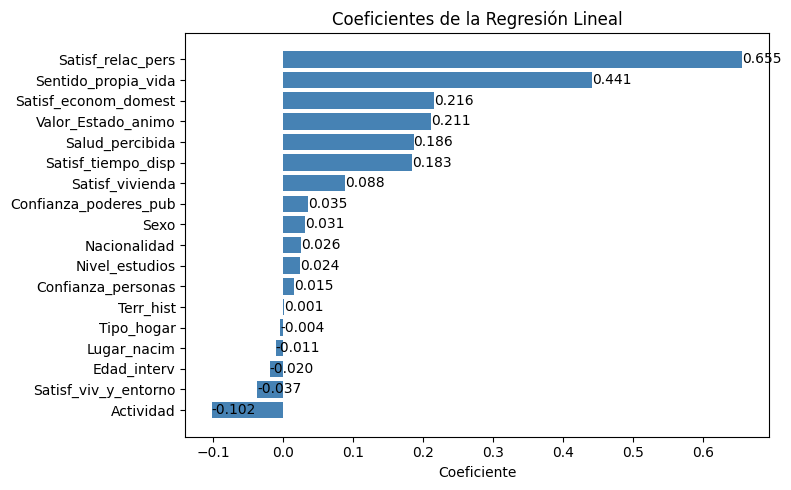

In [15]:
coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    ascending=True
)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    coeficientes['Variable'],
    coeficientes['Coeficiente'],
    color='steelblue'
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.3f}',
        va='center'
    )

plt.title('Coeficientes de la Regresión Lineal')
plt.xlabel('Coeficiente')

plt.tight_layout()
plt.show()

EVALUACIÓN MODELO 1:

Buen resultado para un primer modelo y, además, bastante realista para un problema de bienestar subjetivo.

Los resultados indican que el modelo es capaz de explicar aproximadamente el 59,2% de la variabilidad observada en la satisfacción con la vida. Además, el error medio de predicción es inferior a un punto en una escala de satisfacción de 0 a 10, lo que puede considerarse un nivel de precisión razonable para un fenómeno complejo y subjetivo como el bienestar personal.

No obstante, aunque el rendimiento del modelo es satisfactorio, vamos a valorar hasta qué punto la inclusión de variables demográficas aporta una mejora significativa en la capacidad predictiva. El valor del coeficiente parece indicar que las variables demográficas tienen escaso peso en la definción del bienestar de las personas,y pueden estar produciendo más ruído que otra cosa. Por ello, generamos un segundo modelo de regresión eliminando estas variables.


In [16]:
#Guardo el modelo:

with open("../4_Models/regresion_lineal.pkl", "wb") as f:
    pickle.dump(lr, f)